Importing required libraries.

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Displaying image using cv2.imshow().

In [11]:
raw = cv2.imread("cvtest.jpeg")

if raw is None:
    print("Image not found. Check filename/path.")
else:
    cv2.imshow("raw", raw)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

Converting raw to HSV and displaying it as both RGB and HSV.

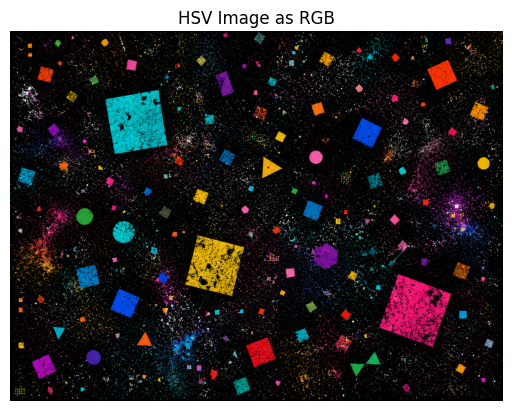

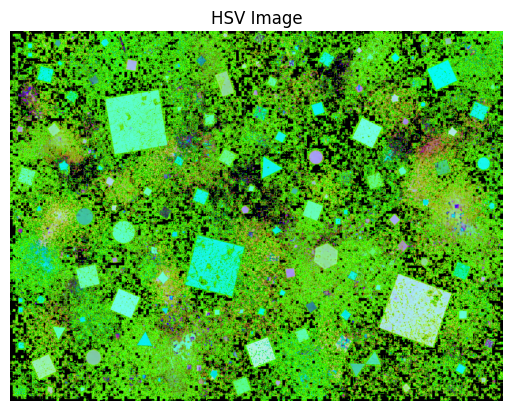

In [12]:
hsv = cv2.cvtColor(raw, cv2.COLOR_BGR2HSV)

hsv_display = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

plt.imshow(hsv_display)
plt.title("HSV Image as RGB")
plt.axis("off")
plt.show()

plt.imshow(hsv)
plt.title("HSV Image")
plt.axis("off")
plt.show()

Creating a simple image, detecting squares within it, and drawing contours around those squares.

In [13]:
canvas = np.zeros((400, 400), dtype = np.uint8)
cv2.rectangle(canvas, (30, 30), (120, 120), 255, -1)
cv2.circle(canvas, (250, 80), 60, 255, -1)
cv2.rectangle(canvas, (50, 250), (150, 350), 255, -1)

cont, _ = cv2.findContours(
    canvas,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
output = cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR)

for index, cnt in enumerate(cont):
    peri = cv2.arcLength(cnt, True)
    
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)

    if len(approx) != 4:
        continue

    if not cv2.isContourConvex(cnt):
        continue

    cv2.drawContours(
        output,
        cont,
        index, 
        (0, 255, 0),
        2
    )

    print("Corners:", len(approx))


cv2.imshow("output", output)
cv2.waitKey(0)
cv2.destroyAllWindows()

Corners: 4
Corners: 4


Creating a boolean color mask for hsv and displaying it.

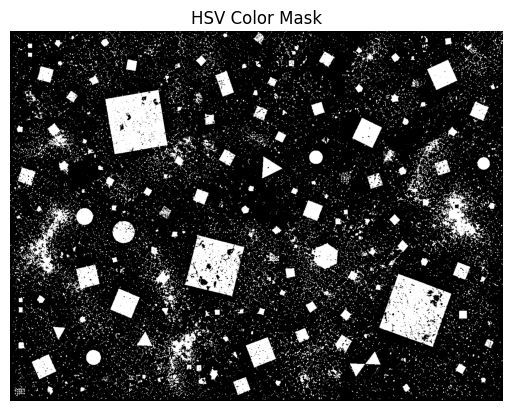

In [14]:
lower = np.array([0, 50, 50])
upper = np.array([179, 255, 255])

mask = cv2.inRange(hsv, lower, upper)

plt.imshow(mask, cmap = "gray")
plt.title("HSV Color Mask")
plt.axis("off")
plt.show()

Opening the image and removing small dots.

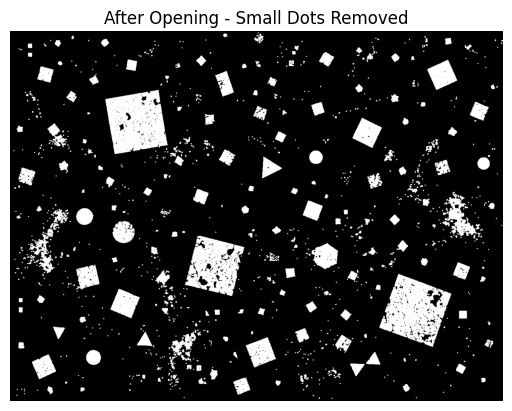

In [15]:
open_kernel = np.ones((3, 3), np.uint8)

opened_mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    open_kernel,
    iterations = 1
)

plt.imshow(opened_mask, cmap = "gray")
plt.title("After Opening - Small Dots Removed")
plt.axis("off")
plt.show()

Detecting and displaying all contours in the image.

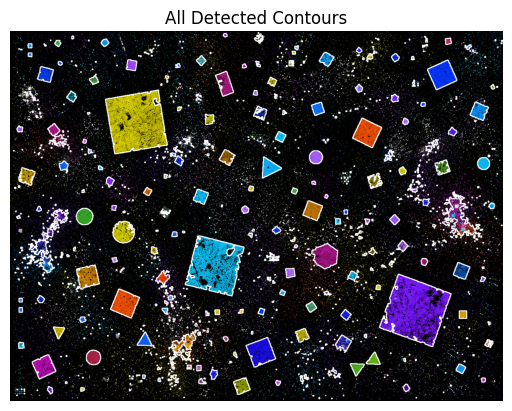

In [16]:
contours, _ = cv2.findContours(
    opened_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

all_contours_img = raw.copy()

cv2.drawContours(
    all_contours_img,
    contours,
    -1,
    (255, 255, 255),
    2
)

plt.imshow(all_contours_img)
plt.title("All Detected Contours")
plt.axis("off")
plt.show()

Detecting and counting the number of squares in cvtest.jpeg

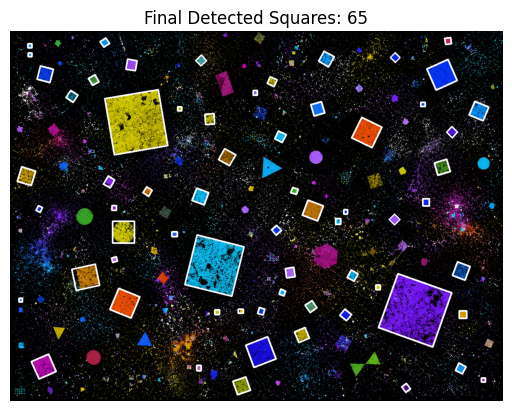

Squares detected:  65


In [17]:
square_count = 0
squares_img = raw.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)

    if area < 100:
        continue
    
    perimeter = cv2.arcLength(cnt, True)

    if perimeter == 0:
        continue

    approx = cv2.approxPolyDP(cnt, 0.04 * perimeter, True)

    if len(approx) != 4:
        continue

    if not cv2.isContourConvex(approx):
        continue

    rect = cv2.minAreaRect(cnt)
    (cx, cy), (w, h), angle = rect

    if w == 0 or h == 0:
        continue
    
    aspect_ratio = max(w, h) / min (w, h)

    if aspect_ratio > 1.25:
        continue

    box_area = w * h
    extent = area / box_area

    if extent < 0.45:
        continue

    square_count += 1

    box = cv2.boxPoints(rect)
    box = np.int32(box)

    cv2.drawContours(squares_img, [box], 0, (255, 255, 255), 3)

plt.imshow(squares_img)
plt.title(f"Final Detected Squares: {square_count}")
plt.axis("off")
plt.show()

print("Squares detected: ", square_count)